# 데이터분석 실무3
- CCTV 설치 데이터 분석

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


## 실습 1. CCTV_in_Seoul.csv 파일을 pandas 로 읽어오세요.
 

In [3]:
# 서울시 구별 CCTV 설치 현황 CSV 파일을 읽어 DataFrame으로 만든다.
CCTV_Seoul = pd.read_csv('./datas/CCTV_in_Seoul.csv')

In [4]:
# 데이터가 정상적으로 불러와졌는지 위쪽 5개 행을 확인한다.
CCTV_Seoul.head()

,기관명,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,2780,1292,430,584,932
1,강동구,773,379,99,155,377
2,강북구,748,369,120,138,204
3,강서구,884,388,258,184,81
4,관악구,1496,846,260,390,613


## 실습 2. 컬럼 중 "기관명" 컬럼명을 "구별" 로 이름을 바꾸세요.

In [5]:
# '기관명' 컬럼의 이름을 '구별'로 변경한다.
CCTV_Seoul = CCTV_Seoul.rename(
    columns={'기관명': '구별'}
)

In [6]:
# '기관명' 컬럼이 '구별'로 변경되었는지 처음 3개 행을 확인한다.
CCTV_Seoul.head(3)

,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,2780,1292,430,584,932
1,강동구,773,379,99,155,377
2,강북구,748,369,120,138,204


## 실습 3. population_in_Seoul.xls 파일을 읽으세요. 

In [7]:
# 서울시 인구 데이터가 저장된 Excel 파일을 읽는다.
pd.read_excel('./datas/population_in_Seoul.xls')

,기간,자치구,세대,인구,인구.1,인구.2,인구.3,인구.4,인구.5,인구.6,인구.7,인구.8,세대당인구,65세이상고령자
0,기간,자치구,세대,합계,합계,합계,한국인,한국인,한국인,등록외국인,등록외국인,등록외국인,세대당인구,65세이상고령자
1,기간,자치구,세대,계,남자,여자,계,남자,여자,계,남자,여자,세대당인구,65세이상고령자
2,2017.1/4,합계,4202888,10197604,5000005,5197599,9926968,4871560,5055408,270636,128445,142191,2.36,1321458
3,2017.1/4,종로구,72654,162820,79675,83145,153589,75611,77978,9231,4064,5167,2.11,25425
4,2017.1/4,중구,59481,133240,65790,67450,124312,61656,62656,8928,4134,4794,2.09,20764
5,2017.1/4,용산구,106544,244203,119132,125071,229456,111167,118289,14747,7965,6782,2.15,36231
6,2017.1/4,성동구,130868,311244,153768,157476,303380,150076,153304,7864,3692,4172,2.32,39997
7,2017.1/4,광진구,158960,372164,180992,191172,357211,174599,182612,14953,6393,8560,2.25,42214
8,2017.1/4,동대문구,159839,369496,182932,186564,354079,177021,177058,15417,5911,9506,2.22,54173
9,2017.1/4,중랑구,177548,414503,206102,208401,409882,204265,205617,4621,1837,2784,2.31,56774


In [8]:
# 필요한 라이브러리가 있으면 설치하세요.

In [9]:
pd.read_excel('./datas/population_in_Seoul.xls')

,기간,자치구,세대,인구,인구.1,인구.2,인구.3,인구.4,인구.5,인구.6,인구.7,인구.8,세대당인구,65세이상고령자
0,기간,자치구,세대,합계,합계,합계,한국인,한국인,한국인,등록외국인,등록외국인,등록외국인,세대당인구,65세이상고령자
1,기간,자치구,세대,계,남자,여자,계,남자,여자,계,남자,여자,세대당인구,65세이상고령자
2,2017.1/4,합계,4202888,10197604,5000005,5197599,9926968,4871560,5055408,270636,128445,142191,2.36,1321458
3,2017.1/4,종로구,72654,162820,79675,83145,153589,75611,77978,9231,4064,5167,2.11,25425
4,2017.1/4,중구,59481,133240,65790,67450,124312,61656,62656,8928,4134,4794,2.09,20764
5,2017.1/4,용산구,106544,244203,119132,125071,229456,111167,118289,14747,7965,6782,2.15,36231
6,2017.1/4,성동구,130868,311244,153768,157476,303380,150076,153304,7864,3692,4172,2.32,39997
7,2017.1/4,광진구,158960,372164,180992,191172,357211,174599,182612,14953,6393,8560,2.25,42214
8,2017.1/4,동대문구,159839,369496,182932,186564,354079,177021,177058,15417,5911,9506,2.22,54173
9,2017.1/4,중랑구,177548,414503,206102,208401,409882,204265,205617,4621,1837,2784,2.31,56774


## 실습 4.population_in_Seoul.xls 파일을 읽으세요.
### header 는 3번째 row 로 사용할 것입니다. 따라서 header = 2  로 셋팅하세요.
### 엑셀파일의 컬럼은  B, D, G, J, N 만 사용할 것입니다.

In [10]:
# 세 번째 행을 컬럼명으로 사용하고 필요한 Excel 컬럼만 선택한다.
pop_Seoul = pd.read_excel(
    './datas/population_in_Seoul.xls',
    header=2,
    usecols='B, D, G, J, N'
)

In [11]:
# 인구 데이터가 원하는 형태로 불러와졌는지 처음 3개 행을 확인한다.
pop_Seoul.head(3)

,자치구,계,계.1,계.2,65세이상고령자
0,합계,10197604.0,9926968.0,270636.0,1321458.0
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0


## 실습 5-1. pop_Seoul 의 컬럼명을 모두 출력하세요.

In [12]:
# pop_Seoul에 들어 있는 모든 컬럼명을 확인한다.
pop_Seoul.columns

Index(['자치구', '계', '계.1', '계.2', '65세이상고령자'], dtype='str')

## 실습 5-2. 컬럼명을 다음처럼 바꿉니다.
### 0번째는 '구별' , 1번째는 '인구수', 2번쨰는 '한국인', 3번째는 '외국인', 4번째는 '고령자'  로 rename

In [13]:
# 기존 컬럼 전체를 분석하기 쉬운 이름으로 변경한다.
pop_Seoul.columns = ['구별', '인구수', '한국인', '외국인', '고령자']

In [14]:
pop_Seoul.head(3)

,구별,인구수,한국인,외국인,고령자
0,합계,10197604.0,9926968.0,270636.0,1321458.0
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0


## 실습 6. CCTV 갯수가 가장 많은 순부터 적은 순으로 정렬한 후, 상위 20개만 화면에 보여주세요.


In [15]:
# CCTV 전체 설치 대수인 '소계'를 기준으로 내림차순 정렬한다.
# 정렬된 결과에서 상위 20개 행만 출력한다.
CCTV_Seoul.sort_values('소계', ascending=False).head(20)

,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,2780,1292,430,584,932
18,양천구,2034,1843,142,30,467
14,서초구,1930,1406,157,336,398
21,은평구,1873,1138,224,278,468
20,용산구,1624,1368,218,112,398
6,구로구,1561,1142,173,246,323
4,관악구,1496,846,260,390,613
16,성북구,1464,1009,78,360,204
10,동대문구,1294,1070,23,198,579
8,노원구,1265,542,57,451,516


## 실습 7. 최근 3년간 CCTV 증가율을 계산하여, dataframe 에 '최근증가율' 컬럼을 추가하세요.
### 증가율 계산  :  (2016 + 2015 + 2014) / 2013이전 * 100

In [16]:
# 증가율 계산에 사용할 연도별 CCTV 설치 대수를 확인한다.
CCTV_Seoul.head(3)

,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,2780,1292,430,584,932
1,강동구,773,379,99,155,377
2,강북구,748,369,120,138,204


In [17]:
# 2014년부터 2016년까지 설치된 CCTV 수를 합한 뒤,
# 2013년도 이전 설치 대수로 나누어 최근 증가율을 계산한다.
CCTV_Seoul['최근증가율'] = (
    CCTV_Seoul['2014년']
    + CCTV_Seoul['2015년']
    + CCTV_Seoul['2016년']
) / CCTV_Seoul['2013년도 이전'] * 100

In [18]:
# '최근증가율' 컬럼이 추가되었는지 처음 3개 행을 확인한다.
CCTV_Seoul.head(3)

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
0,강남구,2780,1292,430,584,932,150.619195
1,강동구,773,379,99,155,377,166.490765
2,강북구,748,369,120,138,204,125.203252


## 실습 8. 최근 3년간 CCTV 증가율이 가장 높은 순으로 5개의 구를 찾으세요.

In [19]:
# 최근증가율 컬럼이 추가되었는지 처음 2개 행을 확인한다.
CCTV_Seoul.head(2)

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
0,강남구,2780,1292,430,584,932,150.619195
1,강동구,773,379,99,155,377,166.490765


In [20]:
# 최근증가율을 큰 값부터 내림차순으로 정렬하고 상위 5개 구를 출력한다.
CCTV_Seoul.sort_values(
    '최근증가율',
    ascending=False
).head(5)

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
22,종로구,1002,464,314,211,630,248.922414
9,도봉구,485,238,159,42,386,246.638655
12,마포구,574,314,118,169,379,212.101911
8,노원구,1265,542,57,451,516,188.929889
1,강동구,773,379,99,155,377,166.490765


## 실습 9-1. 서울시의 인구 데이터 중, 가장 첫번째 행은 필요 없으니, 삭제하세요.

In [21]:
# 첫 번째 행이 어떤 데이터인지 확인한다.
pop_Seoul.head(3)

,구별,인구수,한국인,외국인,고령자
0,합계,10197604.0,9926968.0,270636.0,1321458.0
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0


In [22]:
# 서울시 전체 합계 행을 삭제한다.
pop_Seoul = pop_Seoul.drop(0)
pop_Seoul.head(3)

,구별,인구수,한국인,외국인,고령자
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0


In [23]:
# iloc로 가져오기
# 첫 번째 행을 제외하고 두 번째 행부터 마지막 행까지 가져온다.
pop_Seoul = pop_Seoul.iloc[1:].copy()
pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0
5,광진구,372164.0,357211.0,14953.0,42214.0
6,동대문구,369496.0,354079.0,15417.0,54173.0


In [32]:
pop_Seoul = pop_Seoul.drop(0)
pop_Seoul

,자치구,계,계.1,계.2,65세이상고령자
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0
5,광진구,372164.0,357211.0,14953.0,42214.0
6,동대문구,369496.0,354079.0,15417.0,54173.0
7,중랑구,414503.0,409882.0,4621.0,56774.0
8,성북구,461260.0,449773.0,11487.0,64692.0
9,강북구,330192.0,326686.0,3506.0,54813.0
10,도봉구,348646.0,346629.0,2017.0,51312.0


## 실습 9-2. 서울시의 인구 데이터 중, NaN이 있는지 확인하고, NaN이 있으면 해당 row를 삭제하세요.

In [23]:
# 각 컬럼에 NaN이 몇 개씩 있는지 확인한다.
pop_Seoul.isna().sum()

구별     1
인구수    1
한국인    1
외국인    1
고령자    1
dtype: int64

In [24]:
# 하나 이상의 NaN이 포함된 행을 삭제하고 결과를 다시 저장한다.
pop_Seoul = pop_Seoul.dropna()

# 결측값이 있는 행이 삭제되었는지 데이터를 확인한다.
pop_Seoul

,구별,인구수,한국인,외국인,고령자
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0
5,광진구,372164.0,357211.0,14953.0,42214.0
6,동대문구,369496.0,354079.0,15417.0,54173.0
7,중랑구,414503.0,409882.0,4621.0,56774.0
8,성북구,461260.0,449773.0,11487.0,64692.0
9,강북구,330192.0,326686.0,3506.0,54813.0
10,도봉구,348646.0,346629.0,2017.0,51312.0


In [25]:
# 모든 결측값이 제거되었는지 다시 확인한다.
pop_Seoul.isna().sum()

구별     0
인구수    0
한국인    0
외국인    0
고령자    0
dtype: int64

## 실습 10. '외국인비율' 과 '고령자비율' 두개의 컬럼을 추가하세요.
- 외국인비율 = 외국인 수 / 인구수 * 100
- 고령자비율 = 고령자 수 / 인구수 * 100

In [26]:
# 비율 계산에 사용할 인구수, 외국인, 고령자 컬럼을 확인한다.
pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0
5,광진구,372164.0,357211.0,14953.0,42214.0


In [27]:
# 전체 인구 중 외국인이 차지하는 비율을 백분율로 계산한다.
pop_Seoul['외국인비율'] = (
    pop_Seoul['외국인'] / pop_Seoul['인구수'] * 100
)

# 외국인비율 컬럼이 추가되었는지 확인한다.
pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자,외국인비율
1,종로구,162820.0,153589.0,9231.0,25425.0,5.669451
2,중구,133240.0,124312.0,8928.0,20764.0,6.700690
3,용산구,244203.0,229456.0,14747.0,36231.0,6.038828
4,성동구,311244.0,303380.0,7864.0,39997.0,2.526635
5,광진구,372164.0,357211.0,14953.0,42214.0,4.017852


In [28]:
# 전체 인구 중 고령자가 차지하는 비율을 백분율로 계산한다.
pop_Seoul['고령자비율'] = (
    pop_Seoul['고령자'] / pop_Seoul['인구수'] * 100
)

# 고령자비율 컬럼이 추가되었는지 확인한다.
pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
1,종로구,162820.0,153589.0,9231.0,25425.0,5.669451,15.615404
2,중구,133240.0,124312.0,8928.0,20764.0,6.700690,15.583909
3,용산구,244203.0,229456.0,14747.0,36231.0,6.038828,14.836427
4,성동구,311244.0,303380.0,7864.0,39997.0,2.526635,12.850689
5,광진구,372164.0,357211.0,14953.0,42214.0,4.017852,11.342849


## 실습 11. 외국인 대상으로 장사를 하려 합니다. 외국인이 가장 많은 구와, 외국인비율이 가장 높은 구를 각각 5개씩 찾으세요.

In [29]:
# 외국인 비율이 높은 순으로 상위 5개 구 확인
pop_Seoul.sort_values(
    '외국인비율',
    ascending=False
)[['구별', '외국인', '외국인비율']].head(5)

,구별,외국인,외국인비율
19,영등포구,34913.0,8.663598
18,금천구,18729.0,7.342345
17,구로구,31387.0,7.007998
2,중구,8928.0,6.700690
3,용산구,14747.0,6.038828


In [30]:
# 외국인 수가 많은 순으로 상위 5개 구 확인
pop_Seoul.sort_values(
    '외국인',
    ascending=False
)[['구별', '외국인', '외국인비율']].head(5)

,구별,외국인,외국인비율
19,영등포구,34913.0,8.663598
17,구로구,31387.0,7.007998
18,금천구,18729.0,7.342345
21,관악구,18312.0,3.484582
6,동대문구,15417.0,4.172440


## 실습 12. 고령자 대상 마케팅을 구상 중입니다. 고령자가 가장 많은 구와, 고령자비율이 가장 높은 구를 각각 5개씩 찾으세요.

In [31]:
# 고령자 비율이 높은 순으로 상위 5개 구 확인
pop_Seoul.sort_values(
    '고령자비율',
    ascending=False
)[['구별', '고령자', '고령자비율']].head(5)

,구별,고령자,고령자비율
9,강북구,54813.0,16.600342
1,종로구,25425.0,15.615404
2,중구,20764.0,15.583909
3,용산구,36231.0,14.836427
13,서대문구,48161.0,14.720797


In [32]:
# 실제 고령자 수가 많은 순으로 상위 5개 구 확인
pop_Seoul.sort_values(
    '고령자',
    ascending=False
)[['구별', '고령자', '고령자비율']].head(5)

,구별,고령자,고령자비율
16,강서구,72548.0,12.015794
24,송파구,72506.0,10.862599
12,은평구,72334.0,14.631019
11,노원구,71941.0,12.634883
21,관악구,68082.0,12.955291


## 실습 13. CCTV 데이터와 인구 데이터 합치고 분석하기  

data_result 라는 변수로 저장합니다.

In [33]:
# CCTV 데이터 확인
CCTV_Seoul.head(3)

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
0,강남구,2780,1292,430,584,932,150.619195
1,강동구,773,379,99,155,377,166.490765
2,강북구,748,369,120,138,204,125.203252


In [34]:
# 인구 데이터 확인
pop_Seoul.head(3)

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
1,종로구,162820.0,153589.0,9231.0,25425.0,5.669451,15.615404
2,중구,133240.0,124312.0,8928.0,20764.0,6.700690,15.583909
3,용산구,244203.0,229456.0,14747.0,36231.0,6.038828,14.836427


- cctv 수와 인구랑, 외국인이랑, 고령자랑 상관관계가 있는지 확인해보기 위함

In [35]:
# 두 DataFrame을 공통 컬럼인 '구별'을 기준으로 병합
data_result = pd.merge(
    CCTV_Seoul,
    pop_Seoul,
    on='구별'
)

# 병합 결과 확인
data_result.head()

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,2780,1292,430,584,932,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
1,강동구,773,379,99,155,377,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
2,강북구,748,369,120,138,204,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
3,강서구,884,388,258,184,81,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
4,관악구,1496,846,260,390,613,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


In [36]:
# '소계' 컬럼명을 의미가 분명한 'CCTV갯수'로 변경
data_result = data_result.rename(
    columns={'소계': 'CCTV갯수'}
)

# 변경 결과 확인
data_result.head()

,구별,CCTV갯수,2013년도 이전,2014년,2015년,2016년,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,2780,1292,430,584,932,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
1,강동구,773,379,99,155,377,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
2,강북구,748,369,120,138,204,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
3,강서구,884,388,258,184,81,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
4,관악구,1496,846,260,390,613,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


## 실습 13-1 전처리한 data_result 데이터 프레임을 csv 파일로 저장하세요.

In [37]:
# 저장할 폴더가 없으면 생성
from pathlib import Path

Path('cleaning_data').mkdir(exist_ok=True)

# 저장 위치와 파일명 지정
data_path = 'cleaning_data/cctv_cleaning1.csv'

# DataFrame을 CSV 파일로 저장
data_result.to_csv(
    data_path,
    index=False,
    encoding='utf-8-sig'
)

## 실습 14. data_result 에서, 다음 4개의 컬럼을 모두 버려 버립니다.
### '2013년도 이전', 2014년', '2015년', '2016년' 

In [38]:
# 삭제할 컬럼 확인
data_result.head(3)

,구별,CCTV갯수,2013년도 이전,2014년,2015년,2016년,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,2780,1292,430,584,932,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
1,강동구,773,379,99,155,377,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
2,강북구,748,369,120,138,204,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342


In [39]:
# 분석에 사용하지 않을 연도별 CCTV 설치 컬럼 삭제
data_result = data_result.drop(
    columns=['2013년도 이전', '2014년', '2015년', '2016년']
)

In [40]:
# 강서구 데이터로 컬럼 삭제 결과 확인
data_result.loc[data_result['구별'] == '강서구']

,구별,CCTV갯수,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
3,강서구,884,134.793814,603772.0,597248.0,6524.0,72548.0,1.08054,12.015794


In [41]:
# 전체 데이터 앞부분 확인
data_result.head()

,구별,CCTV갯수,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,2780,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
1,강동구,773,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
2,강북구,748,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
3,강서구,884,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
4,관악구,1496,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


## 실습 15-1. data_result 의 인덱스를, '구별' 로 바꿔 줍니다.

In [42]:
# '구별' 컬럼을 DataFrame의 인덱스로 설정
data_result = data_result.set_index('구별')

# 변경 결과 확인
data_result.head()

,CCTV갯수,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
강남구,2780,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
강동구,773,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
강북구,748,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
강서구,884,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
관악구,1496,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


In [43]:
# 인덱스를 이용해 강서구 데이터 조회
data_result.loc['강서구']

CCTV갯수       884.000000
최근증가율        134.793814
인구수       603772.000000
한국인       597248.000000
외국인         6524.000000
고령자        72548.000000
외국인비율          1.080540
고령자비율         12.015794
Name: 강서구, dtype: float64

## 실습 15-2. 이 데이터프레임을 csv 파일로 저장합니다.
### 저장 위치 및 파일명 : cleaning_data/cctv_cleaning2.csv

In [44]:
# 저장할 폴더가 없으면 생성
from pathlib import Path

Path('cleaning_data').mkdir(exist_ok=True)

# 저장 위치와 파일명 지정
data_path = 'cleaning_data/cctv_cleaning2.csv'

# 구별 인덱스를 포함하여 CSV 파일로 저장
data_result.to_csv(
    data_path,
    encoding='utf-8-sig'
)

In [45]:
# CSV 파일을 읽으면서 '구별' 컬럼을 인덱스로 지정
data_result2 = pd.read_csv(
    data_path,
    index_col='구별'
)

# 불러온 데이터 확인
data_result2.head()

,CCTV갯수,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
강남구,2780,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
강동구,773,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
강북구,748,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
강서구,884,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
관악구,1496,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


## 실습 16. 상관 관계 분석에 대해서 알아봅니다.
### https://ko.wikipedia.org/wiki/%EC%83%81%EA%B4%80_%EB%B6%84%EC%84%9D

상관계수는 -1부터 1까지의 값을 갖는다.

1일 때 완벽한 양의 상관관계가 되고, 

-1일 때 완벽한 음의 상관관계가 된다. 

0이라면 별다른 상관관계가 없음을 의미한다.


-  인공지능을 만들때 관련이 있는 데이터를 추출하기 위함. -> 정확도가 중요함.

In [47]:
# 사용 형식 예시:
# data_result[['실제 컬럼명1', '실제 컬럼명2']].corr()

## 실습 17. CCTV의 갯수와 고령자 비율의 상관관계를 분석하세요.

In [48]:
# 분석에 사용할 컬럼 확인
data_result[['CCTV갯수', '고령자비율']].head()

,CCTV갯수,고령자비율
구별,,
강남구,2780,11.072217
강동구,773,12.051638
강북구,748,16.600342
강서구,884,12.015794
관악구,1496,12.955291


In [49]:
# CCTV 개수와 고령자 비율의 상관계수 계산
data_result[['CCTV갯수', '고령자비율']].corr()

,CCTV갯수,고령자비율
CCTV갯수,1.000000,-0.280786
고령자비율,-0.280786,1.000000


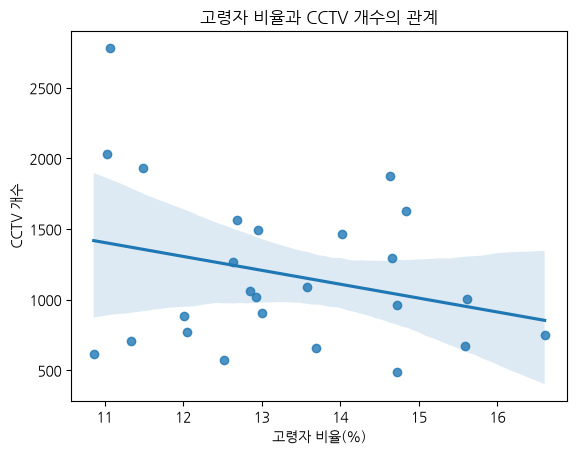

In [50]:
# CCTV 개수와 고령자 비율의 관계 시각화
sb.regplot(
    data=data_result,
    x='고령자비율',
    y='CCTV갯수'
)

plt.title('고령자 비율과 CCTV 개수의 관계')
plt.xlabel('고령자 비율(%)')
plt.ylabel('CCTV 개수')
plt.show()

## 실습 18. CCTV의 갯수와 외국인 비율의 상관관계를 분석하세요.

In [51]:
# CCTV 개수와 외국인 비율의 상관계수 계산
data_result[['CCTV갯수', '외국인비율']].corr()

,CCTV갯수,외국인비율
CCTV갯수,1.000000,-0.136074
외국인비율,-0.136074,1.000000


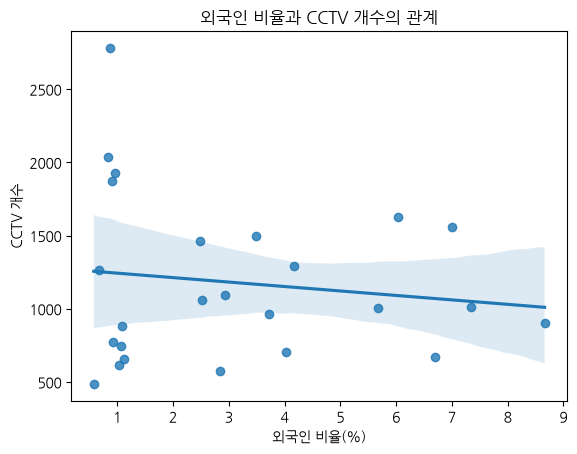

In [52]:
# CCTV 개수와 외국인 비율의 관계 시각화
sb.regplot(
    data=data_result,
    x='외국인비율',
    y='CCTV갯수'
)

plt.title('외국인 비율과 CCTV 개수의 관계')
plt.xlabel('외국인 비율(%)')
plt.ylabel('CCTV 개수')
plt.show()

## 실습 19. CCTV의 갯수와 인구수의 상관관계를 분석하세요.

In [53]:
# CCTV 개수와 인구수의 상관계수 계산
data_result[['CCTV갯수', '인구수']].corr()

,CCTV갯수,인구수
CCTV갯수,1.000000,0.306342
인구수,0.306342,1.000000


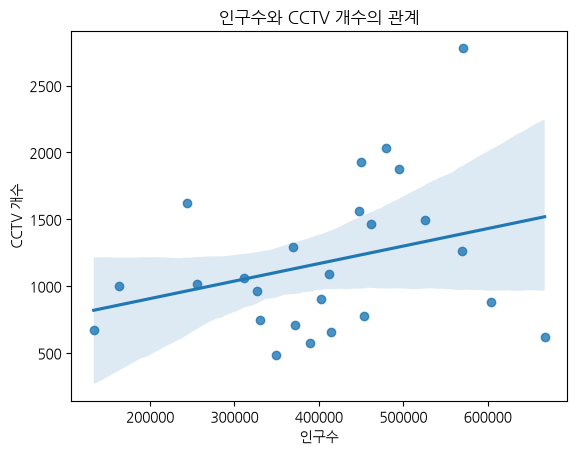

In [54]:
# CCTV 개수와 인구수의 관계 시각화
sb.regplot(
    data=data_result,
    x='인구수',
    y='CCTV갯수'
)

plt.title('인구수와 CCTV 개수의 관계')
plt.xlabel('인구수')
plt.ylabel('CCTV 개수')
plt.show()

## 실습 20. 각 구의 CCTV의 갯수를 bar로 나타내세요.
### pandas dataframe.plot 함수 사용

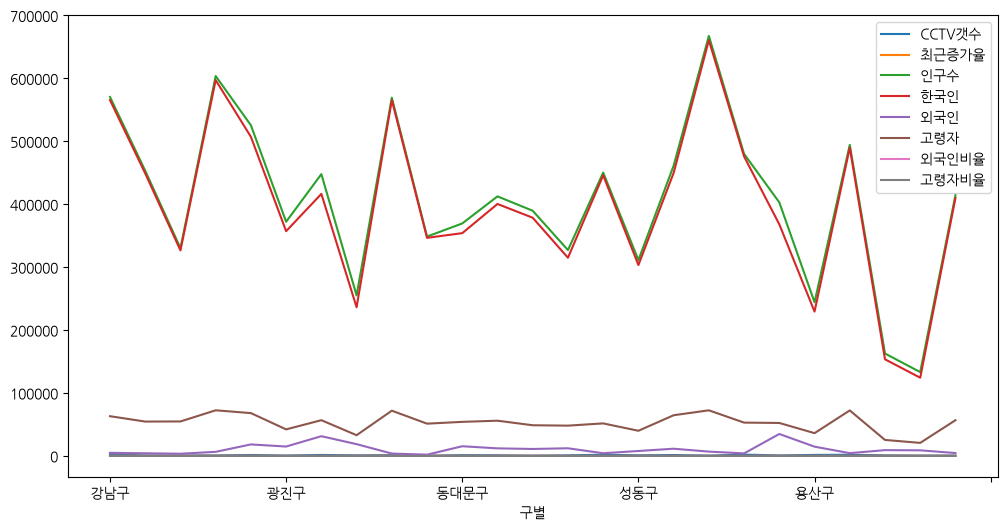

In [55]:
# x 축은 인덱스, y축은 데이터로 표시하는 함수
# DataFrame의 숫자 컬럼들을 기본 선 그래프로 표시
data_result.plot(figsize=(12, 6))
plt.show()

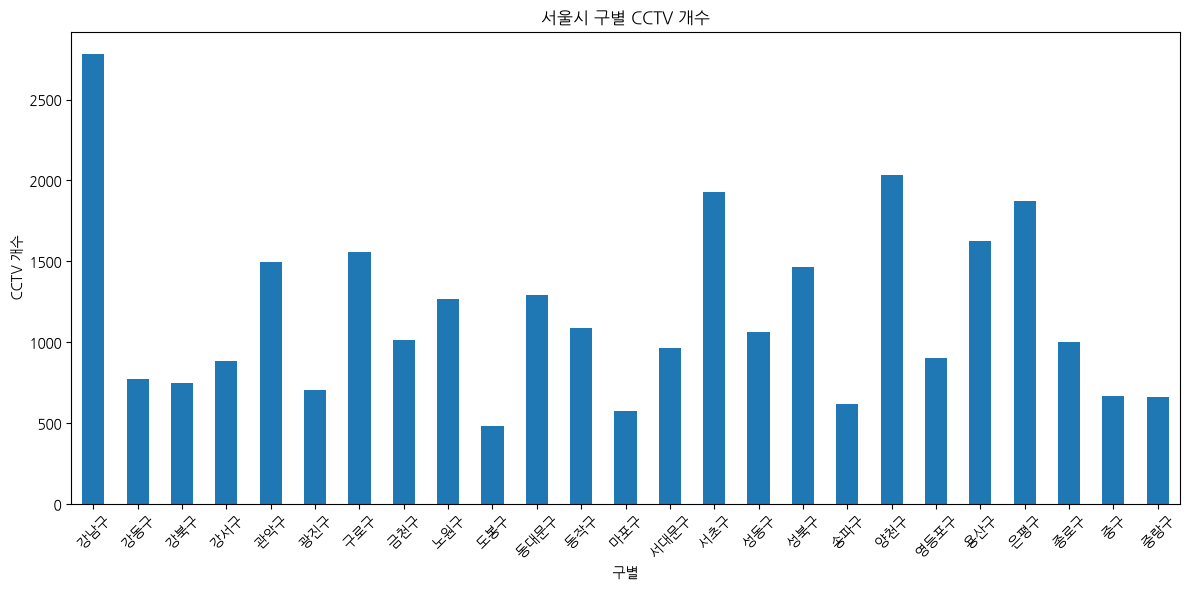

In [58]:
# 각 구의 CCTV 개수를 막대그래프로 시각화
data_result['CCTV갯수'].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('서울시 구별 CCTV 개수')
plt.xlabel('구별')
plt.ylabel('CCTV 개수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 실습 21. 각 구의 CCTV의 갯수를, 먼저 소팅(큰순)한 후,  bar로 나타내세요.

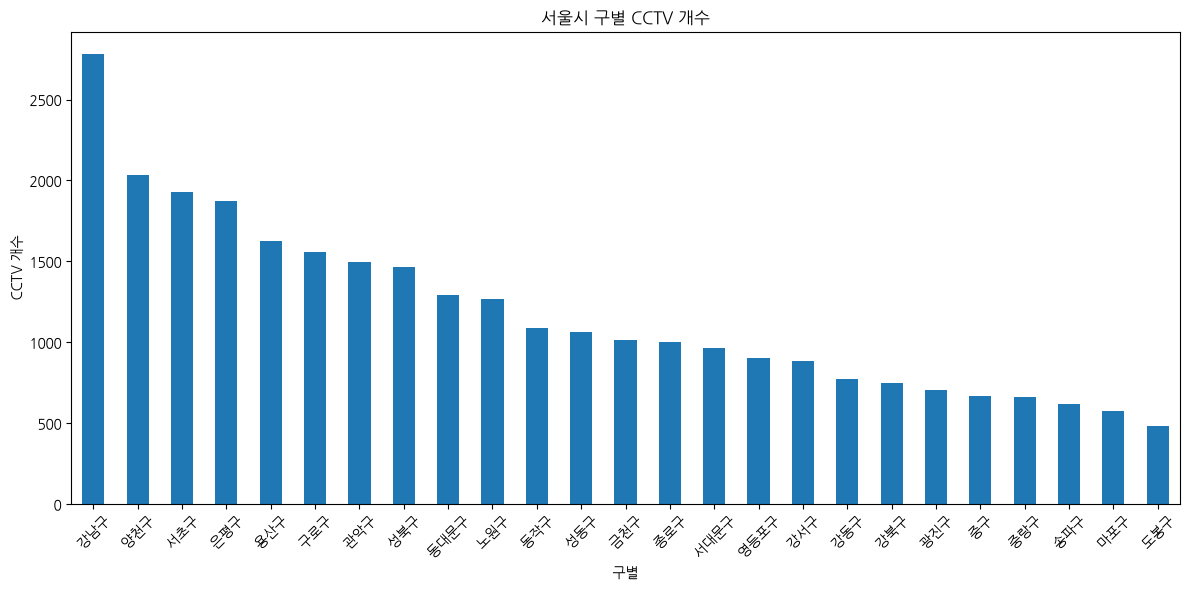

In [59]:
# CCTV 개수를 많은 순으로 정렬하여 세로 막대그래프로 표시
data_result['CCTV갯수'].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('서울시 구별 CCTV 개수')
plt.xlabel('구별')
plt.ylabel('CCTV 개수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

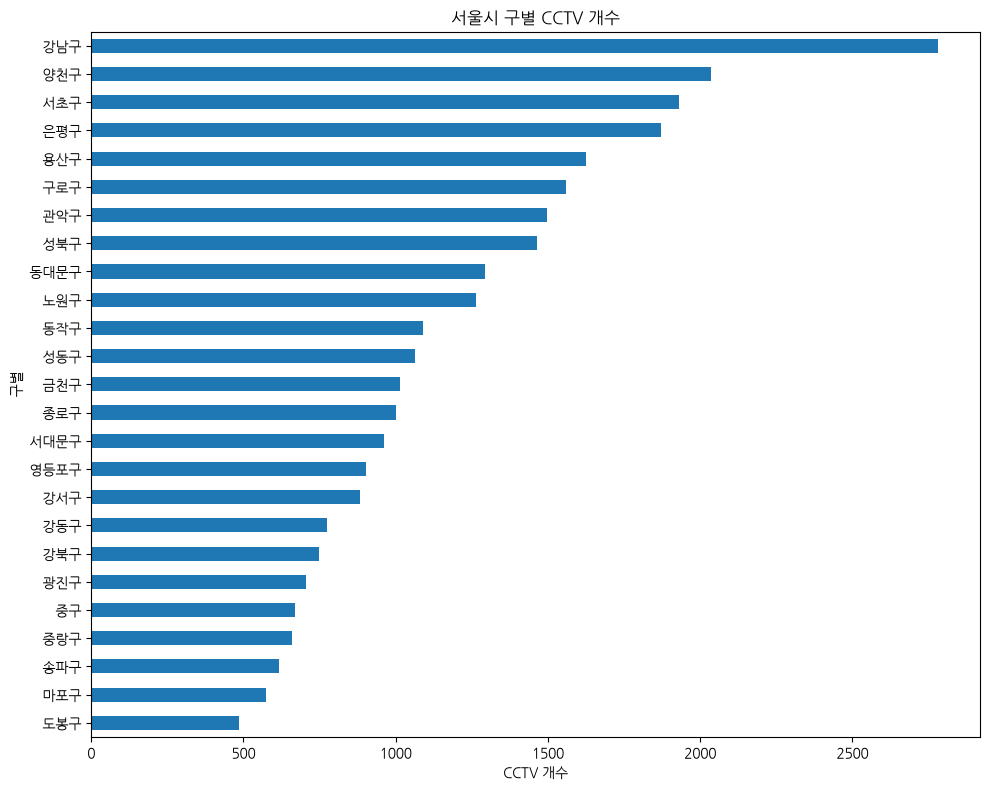

In [60]:
# 가로 막대그래프에서는 큰 값이 위에 오도록 오름차순 정렬
data_result['CCTV갯수'].sort_values().plot(
    kind='barh',
    figsize=(10, 8)
)

plt.title('서울시 구별 CCTV 개수')
plt.xlabel('CCTV 개수')
plt.ylabel('구별')
plt.tight_layout()
plt.show()

## 실습 22. 인구 한명당 CCTV의 비율을 계산하고, 이를 각 구별로 CCTV비율이 얼마인지 bar로 나타내세요.

In [62]:
# 인구수 대비 CCTV 개수를 백분율로 계산
data_result['인구1인당CCTV비율'] = (
    data_result['CCTV갯수'] / data_result['인구수'] * 100
)

# 계산 결과 확인
data_result.head()

,CCTV갯수,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,인구1인당CCTV비율
구별,,,,,,,,,
강남구,2780,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217,0.487292
강동구,773,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638,0.170552
강북구,748,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342,0.226535
강서구,884,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794,0.146413
관악구,1496,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291,0.284673


In [113]:
data_result['인구1인당CCTV비율'] = data_result['CCTV갯수']/data_result['인구수'] * 100
data_result.head()

,CCTV갯수,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,인구1인당CCTV비율
구별,,,,,,,,,
강남구,2780,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217,0.487292
강동구,773,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638,0.170552
강북구,748,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342,0.226535
강서구,884,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794,0.146413
관악구,1496,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291,0.284673


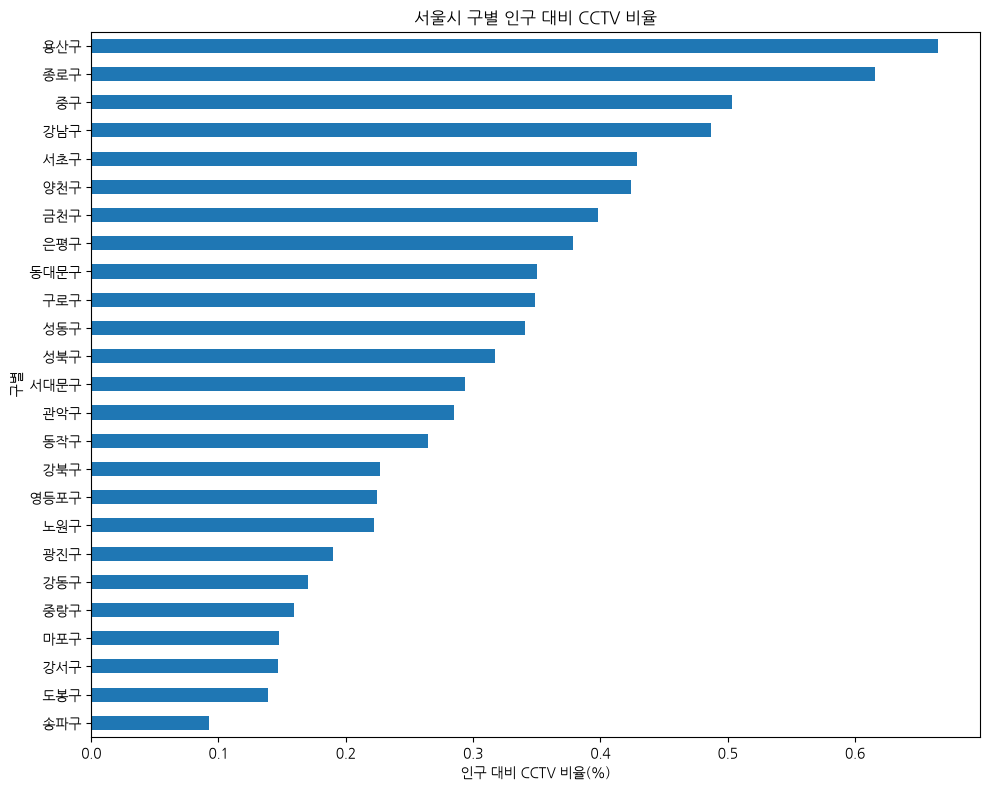

In [63]:
# 인구 대비 CCTV 비율을 정렬하여 가로 막대그래프로 표시
data_result['인구1인당CCTV비율'].sort_values().plot(
    kind='barh',
    figsize=(10, 8)
)

plt.title('서울시 구별 인구 대비 CCTV 비율')
plt.xlabel('인구 대비 CCTV 비율(%)')
plt.ylabel('구별')
plt.tight_layout()
plt.show()

## 실습 23. 인구수와 CCTV갯수가 어떤 분포인지, scatter로 나타내기

<Axes: xlabel='인구수', ylabel='CCTV갯수'>

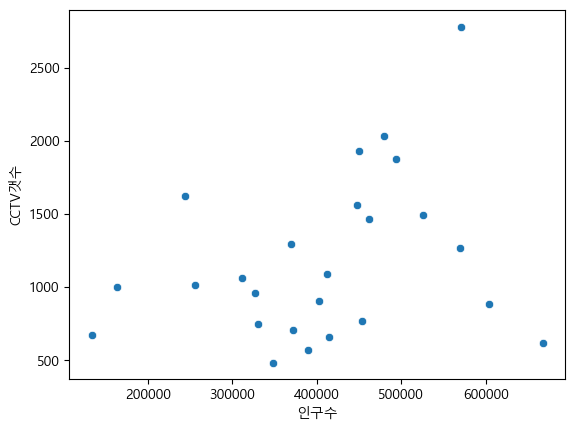

In [115]:
# 인구수와 CCTV갯수가 어떤 분포인지, scatter로 나타내기


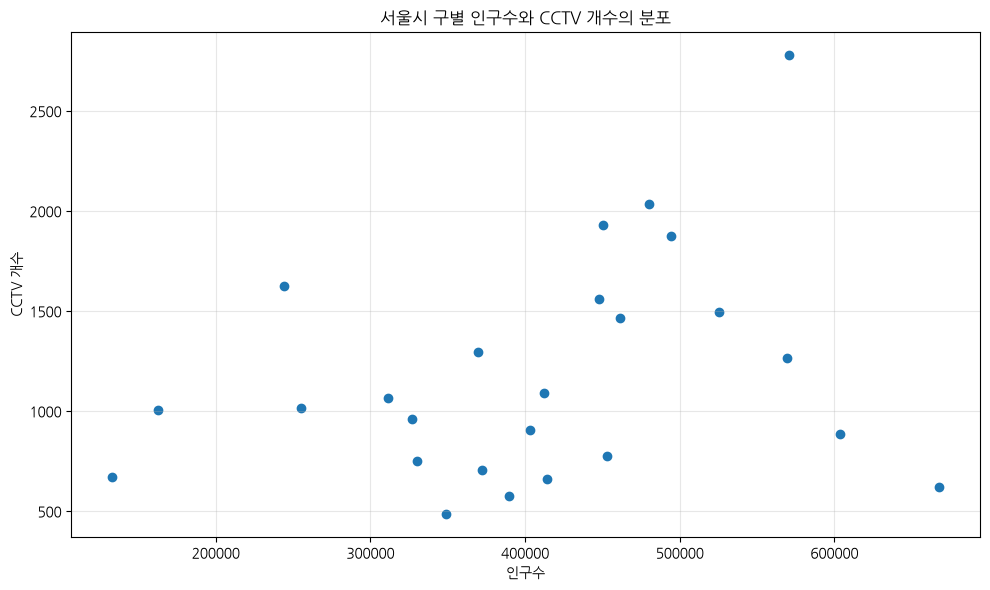

In [64]:
# 인구수를 x축, CCTV 개수를 y축으로 산점도 그리기
plt.figure(figsize=(10, 6))

plt.scatter(
    data_result['인구수'],
    data_result['CCTV갯수']
)

plt.title('서울시 구별 인구수와 CCTV 개수의 분포')
plt.xlabel('인구수')
plt.ylabel('CCTV 개수')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()